# EDA: Исследование активности респондентов

Цель: Понять распределение активности и выявить аномальные паттерны

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Библиотеки загружены')

Библиотеки загружены


## 1. Загрузка данных

In [2]:
# Загружаем все файлы парquet
files = sorted(glob.glob('../data_train/month=*/part-*.parquet'))
print(f'Найдено {len(files)} файлов:')
for f in files:
    print(f'  {f}')

# Объединяем все данные
dfs = [pd.read_parquet(f) for f in files]
df = pd.concat(dfs, ignore_index=True)
print(f'\nОбщий размер: {df.shape}')
print(f'Уникальных респондентов: {df["SubjectID"].nunique()}')
print(f'Уникальных брендов: {df["Brand"].nunique()}')
print(f'Дата диапазон: {df["researchdate"].min()} - {df["researchdate"].max()}')

Найдено 9 файлов:
  ../data_train\month=2025-06-01\part-00000-6c86f944-e574-4f90-90af-62f188113fcf.c000.snappy.parquet
  ../data_train\month=2025-07-01\part-00000-21dc5986-4bcf-4f68-90e9-9bc3467d179d.c000.snappy.parquet
  ../data_train\month=2025-07-01\part-00000-6c86f944-e574-4f90-90af-62f188113fcf.c000.snappy.parquet
  ../data_train\month=2025-08-01\part-00000-21dc5986-4bcf-4f68-90e9-9bc3467d179d.c000.snappy.parquet
  ../data_train\month=2025-08-01\part-00000-43f58531-b928-4f38-977b-da5304d8c2af.c000.snappy.parquet
  ../data_train\month=2025-09-01\part-00000-43f58531-b928-4f38-977b-da5304d8c2af.c000.snappy.parquet
  ../data_train\month=2025-09-01\part-00000-fb6b236e-6840-4a81-a7fd-d43ffdc20800.c000.snappy.parquet
  ../data_train\month=2025-10-01\part-00000-b452d37c-6672-4bff-913b-e438a1c16e2a.c000.snappy.parquet
  ../data_train\month=2025-10-01\part-00000-fb6b236e-6840-4a81-a7fd-d43ffdc20800.c000.snappy.parquet

Общий размер: (280458, 29)
Уникальных респондентов: 24009
Уникальных бре

In [3]:
# Загружаем пример аномалий
anomalies_example = pd.read_parquet('../data_train/examples/invalidResp_05-2025.parquet')
print('Пример удаленных респондентов (май 2025):')
print(f'Размер: {anomalies_example.shape}')
print(f'Уникальных респондентов: {anomalies_example["SubjectID"].nunique()}')
print(anomalies_example.head(10))

Пример удаленных респондентов (май 2025):
Размер: (36, 4)
Уникальных респондентов: 33
    CategoryNameDelivery        Brand researchdate            SubjectID
0        Детское питание        агуша   2025-05-02  1585271561336863782
1         Корм для кошек     pro plan   2025-05-02  1585271561336939603
2       Краски для волос        estel   2025-05-03  3891115984388077771
3  Смарт-часы и браслеты       xiaomi   2025-05-04  1954572816503618427
4             Подгузники      pampers   2025-05-05  3819059496266608833
5        Крупная техника     maunfeld   2025-05-06  6710375698481685377
6              Смартфоны       xiaomi   2025-05-07  1585271561336916995
7         Корм для кошек  royal canin   2025-05-07  5476385132355153731
8              Смартфоны  tecno spark   2025-05-07  1585271561336901830
9        Детское питание    фрутоняня   2025-05-08  6196961100373024751


## 2. Основная статистика

In [4]:
# Активность по респондентам
resp_activity = df.groupby('SubjectID').size().reset_index(name='query_count')
print('Распределение активности по респондентам:')
print(resp_activity['query_count'].describe())
print(f'\nТоп-10 самых активных:')
print(resp_activity.nlargest(10, 'query_count'))

Распределение активности по респондентам:
count    24009.000000
mean        11.681369
std         22.819130
min          1.000000
25%          2.000000
50%          5.000000
75%         12.000000
max        762.000000
Name: query_count, dtype: float64

Топ-10 самых активных:
                 SubjectID  query_count
1764    729595691934241985          762
7953   1585271561337045199          654
5540   1585271561336866458          567
11328  2882308749924541139          493
13343  4035232106963127754          477
21432  7576643904375722625          467
15604  5260212023980595118          437
8269   1585271561337054434          418
11842  3098483602160404120          409
1459    576467810957597286          408


In [5]:
# Активность по брендам
brand_activity = df.groupby('Brand').size().reset_index(name='query_count')
print('Распределение активности по брендам:')
print(brand_activity['query_count'].describe())
print(f'\nТоп-15 самых популярных брендов:')
print(brand_activity.nlargest(15, 'query_count'))

Распределение активности по брендам:
count     8177.000000
mean        34.298398
std        359.253309
min          1.000000
25%          1.000000
50%          2.000000
75%          7.000000
max      18679.000000
Name: query_count, dtype: float64

Топ-15 самых популярных брендов:
               Brand  query_count
361     apple iphone        18679
5738  samsung galaxy        14358
7096          xiaomi         8830
2925           honor         8637
5474           redmi         8474
5456          realme         7471
5238            poco         5863
2949          huawei         5300
8175          яндекс         4363
5736         samsung         4070
4690            nike         4068
91            adidas         3427
3066         infinix         3312
6099            sony         2136
1464           crocs         2013


In [6]:
# Активность по категориям доставки
cat_activity = df.groupby('CategoryNameDelivery').size().reset_index(name='query_count')
print('Распределение по категориям доставки:')
print(cat_activity.sort_values('query_count', ascending=False))

Распределение по категориям доставки:
                      CategoryNameDelivery  query_count
18                               Смартфоны        94917
14                                  Одежда        25970
13                                   Обувь        25111
12                           Малая техника        23548
8                          Крупная техника        21083
0                             Аудиотехника        18407
19                      Средства для волос         7500
5                           Корм для кошек         7289
17                   Смарт-часы и браслеты         6801
23  Средства для умывания и ухода за лицом         6464
2                   Детские одежда и обувь         5863
26                       Товары для стирки         4864
29         Универсальные чистящие средства         3649
30                    Уход за полостью рта         3304
3                          Детское питание         3083
16                              Подгузники         2993
7         

## 3. Анализ аномалий: респондент × бренд × день

In [7]:
# Активность на уровне responder-brand-day
df['researchdate'] = pd.to_datetime(df['researchdate'])

responder_brand_day = df.groupby(['SubjectID', 'Brand', 'researchdate']).size().reset_index(name='count')
print('Активность на уровне респондент-бренд-день:')
print(responder_brand_day['count'].describe())
print(f'\nМакс активность: {responder_brand_day["count"].max()}')
print(f'\nТоп-20 случаев максимальной активности:')
print(responder_brand_day.nlargest(20, 'count'))

Активность на уровне респондент-бренд-день:
count    191123.000000
mean          1.467422
std           1.151135
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          56.000000
Name: count, dtype: float64

Макс активность: 56

Топ-20 случаев максимальной активности:
                  SubjectID            Brand researchdate  count
100345  3098482975285223429   samsung galaxy   2025-07-24     56
50395   1585271561336878046            vitek   2025-08-13     39
76778   1729388589032331985           adidas   2025-06-08     39
40803   1585271561336741967  maison margiela   2025-10-22     36
76776   1729388589032331985           adidas   2025-06-05     36
162394  6710377279947371714             nike   2025-08-16     36
169509  7349882588402794305             poco   2025-07-09     34
63960   1585271561337010551          essence   2025-09-22     29
86010   2305848744076622793          leonord   2025-10-21     27
127179  5197164996113048095     

In [8]:
# Распределение активности по дням недели и часам
print('Запросы в расчете:"Start" column:')
print(df['Start'].dtype)
print(df['Start'].head())

# Добавим час
df['hour'] = pd.to_datetime(df['Start']).dt.hour
df['day_of_week'] = pd.to_datetime(df['Start']).dt.day_name()

print('\nАктивность по часам дня:')
hourly = df['hour'].value_counts().sort_index()
print(hourly)

Запросы в расчете:"Start" column:
datetime64[ns]
0   2025-06-29 14:22:41
1   2025-06-03 09:56:47
2   2025-06-30 10:37:36
3   2025-06-29 22:42:36
4   2025-06-03 22:22:25
Name: Start, dtype: datetime64[ns]

Активность по часам дня:
hour
0     10404
1      5220
2      2926
3      1770
4      1408
5      1819
6      3743
7      6631
8      9374
9     12522
10    14770
11    15516
12    16294
13    16480
14    16459
15    16447
16    15880
17    15459
18    15383
19    15500
20    17037
21    18287
22    17535
23    13594
Name: count, dtype: int64


## 4. Сравнение: нормальные vs аномальные респонденты

In [9]:
# Получаем список аномальных респондентов из примера
anomaly_subjects = set(anomalies_example['SubjectID'].unique())
print(f'Количество аномальных респондентов в примере: {len(anomaly_subjects)}')

# Анализ их активности
anomaly_df = df[df['SubjectID'].isin(anomaly_subjects)]
normal_df = df[~df['SubjectID'].isin(anomaly_subjects)]

print(f'\nАномальные: {len(anomaly_df)} записей')
print(f'Нормальные: {len(normal_df)} записей')

print('\nАктивность аномальных по респондентам:')
print(anomaly_df.groupby('SubjectID').size().describe())

print('\nАктивность нормальных по респондентам:')
print(normal_df.groupby('SubjectID').size().describe())

Количество аномальных респондентов в примере: 33

Аномальные: 1206 записей
Нормальные: 279252 записей

Активность аномальных по респондентам:
count     30.000000
mean      40.200000
std       33.230024
min        2.000000
25%       13.750000
50%       34.000000
75%       67.500000
max      130.000000
dtype: float64

Активность нормальных по респондентам:
count    23979.000000
mean        11.645690
std         22.781787
min          1.000000
25%          2.000000
50%          5.000000
75%         12.000000
max        762.000000
dtype: float64


In [10]:
# Сравнение концентрации на брендах
print('Топ бренды для аномальных респондентов:')
print(anomaly_df['Brand'].value_counts().head(10))

print('\nТоп бренды для нормальных респондентов:')
print(normal_df['Brand'].value_counts().head(10))

Топ бренды для аномальных респондентов:
Brand
honor             134
apple iphone       90
samsung galaxy     76
xiaomi             49
redmi              38
pioneer            35
nestle nan         31
poco               27
pampers            27
sony               18
Name: count, dtype: int64

Топ бренды для нормальных респондентов:
Brand
apple iphone      18589
samsung galaxy    14282
xiaomi             8781
honor              8503
redmi              8436
realme             7464
poco               5836
huawei             5291
яндекс             4347
nike               4064
Name: count, dtype: int64


## 5. Анализ по демографическим признакам

In [11]:
# Список демографических колонок
demo_cols = [col for col in df.columns if col in ['ПОЛ', 'ВОЗРАСТ', 'ДОХОД', 'ОБРАЗОВАНИЕ_ГРУПП', 'ЗАНЯТОСТЬ_ГРУПП']]
print(f'Демографические колонки: {demo_cols}')

# Переводим кириллицу для удобства
df_cols = df.columns.tolist()
print(f'\nВсе колонки ({len(df_cols)}):') 
for i, col in enumerate(df_cols):
    print(f'{i}: {col}')

Демографические колонки: []

Все колонки (31):
0: SubjectID
1: QueryText
2: BrandID
3: Category1ID
4: Category2ID
5: Category3ID
6: Brand
7: Category1
8: Category2
9: Category3
10: CategoryNameDelivery
11: ResourceName
12: ResourceType
13: UseType
14: Platform
15: Пол
16: Возраст
17: Регион
18: Федеральный_округ
19: Количество_детей
20: Занятость
21: Доход
22: Weight
23: week_weight
24: month_weight
25: Start
26: researchdate
27: week
28: BrandinDelivery
29: hour
30: day_of_week


In [12]:
# Анализ уникальных значений в потенциальных демо-колонках
potential_demo = ['ПОЛ', 'ВОЗРАСТ', 'ДОХОД', 'ОБРАЗОВАНИЕ_ГРУПП', 'ЗАНЯТОСТЬ_ГРУПП']

for col in potential_demo:
    if col in df.columns:
        print(f'\n{col}:')
        print(df[col].value_counts().head())
    else:
        print(f'\n{col}: не найдена')


ПОЛ: не найдена

ВОЗРАСТ: не найдена

ДОХОД: не найдена

ОБРАЗОВАНИЕ_ГРУПП: не найдена

ЗАНЯТОСТЬ_ГРУПП: не найдена


## 6. Визуализация

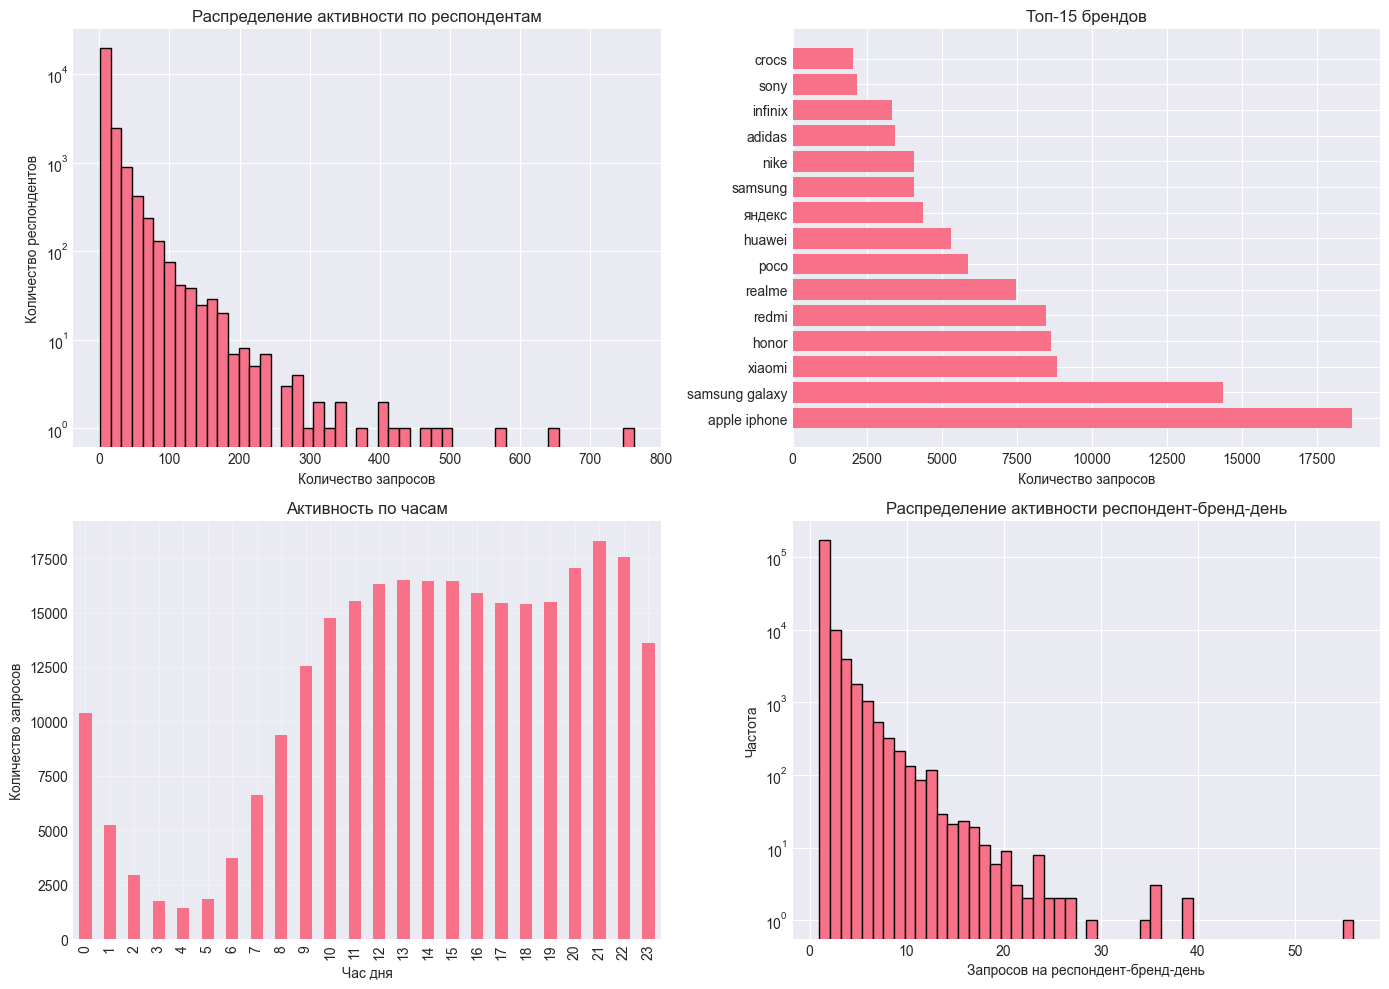

График сохранен в data_processed/01_distributions.png


In [13]:
# График распределения активности
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Активность по респондентам
axes[0, 0].hist(resp_activity['query_count'], bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Количество запросов')
axes[0, 0].set_ylabel('Количество респондентов')
axes[0, 0].set_title('Распределение активности по респондентам')
axes[0, 0].set_yscale('log')

# Активность по брендам
top_brands = brand_activity.nlargest(15, 'query_count')
axes[0, 1].barh(range(len(top_brands)), top_brands['query_count'])
axes[0, 1].set_yticks(range(len(top_brands)))
axes[0, 1].set_yticklabels(top_brands['Brand'])
axes[0, 1].set_xlabel('Количество запросов')
axes[0, 1].set_title('Топ-15 брендов')

# Активность по часам
hourly.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_xlabel('Час дня')
axes[1, 0].set_ylabel('Количество запросов')
axes[1, 0].set_title('Активность по часам')
axes[1, 0].grid(True, alpha=0.3)

# Распределение count на уровне resp-brand-day
axes[1, 1].hist(responder_brand_day['count'], bins=50, edgecolor='black')
axes[1, 1].set_xlabel('Запросов на респондент-бренд-день')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_title('Распределение активности респондент-бренд-день')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.savefig('../data_processed/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('График сохранен в data_processed/01_distributions.png')

## 7. Ключевые выводы для разработки алгоритма

In [14]:
# Расчет статистики для разработки порогов
print('=== СТАТИСТИКА ДЛЯ ПОРОГОВ АНОМАЛИЙ ===')
print(f'\nАктивность респондент-бренд-день:')
print(f'  Mean: {responder_brand_day["count"].mean():.2f}')
print(f'  Std: {responder_brand_day["count"].std():.2f}')
print(f'  Median: {responder_brand_day["count"].median():.2f}')
print(f'  Q75: {responder_brand_day["count"].quantile(0.75):.2f}')
print(f'  Q95: {responder_brand_day["count"].quantile(0.95):.2f}')
print(f'  Q99: {responder_brand_day["count"].quantile(0.99):.2f}')
print(f'  Max: {responder_brand_day["count"].max():.2f}')

# Расчет IQR
Q1 = responder_brand_day['count'].quantile(0.25)
Q3 = responder_brand_day['count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'\nIQR метод:')
print(f'  Q1: {Q1:.2f}')
print(f'  Q3: {Q3:.2f}')
print(f'  IQR: {IQR:.2f}')
print(f'  Нижняя граница: {lower_bound:.2f}')
print(f'  Верхняя граница (порог аномалии): {upper_bound:.2f}')

# Предполагаемые аномалии
anomalies_iqr = responder_brand_day[responder_brand_day['count'] > upper_bound]
print(f'\nПредполагаемые аномалии (IQR метод): {len(anomalies_iqr)}')
print(anomalies_iqr.nlargest(10, 'count'))

=== СТАТИСТИКА ДЛЯ ПОРОГОВ АНОМАЛИЙ ===

Активность респондент-бренд-день:
  Mean: 1.47
  Std: 1.15
  Median: 1.00
  Q75: 2.00
  Q95: 3.00
  Q99: 6.00
  Max: 56.00

IQR метод:
  Q1: 1.00
  Q3: 2.00
  IQR: 1.00
  Нижняя граница: -0.50
  Верхняя граница (порог аномалии): 3.50

Предполагаемые аномалии (IQR метод): 8391
                  SubjectID            Brand researchdate  count
100345  3098482975285223429   samsung galaxy   2025-07-24     56
50395   1585271561336878046            vitek   2025-08-13     39
76778   1729388589032331985           adidas   2025-06-08     39
40803   1585271561336741967  maison margiela   2025-10-22     36
76776   1729388589032331985           adidas   2025-06-05     36
162394  6710377279947371714             nike   2025-08-16     36
169509  7349882588402794305             poco   2025-07-09     34
63960   1585271561337010551          essence   2025-09-22     29
86010   2305848744076622793          leonord   2025-10-21     27
127179  5197164996113048095     

In [15]:
# Z-score анализ
from scipy import stats

responder_brand_day['z_score'] = np.abs(stats.zscore(responder_brand_day['count']))

print('Z-score анализ:')
for threshold in [2, 2.5, 3]:
    anomalies_z = responder_brand_day[responder_brand_day['z_score'] > threshold]
    print(f'  Z > {threshold}: {len(anomalies_z)} аномалий')

print('\nТоп-20 по Z-score:')
print(responder_brand_day.nlargest(20, 'z_score')[['SubjectID', 'Brand', 'researchdate', 'count', 'z_score']])

Z-score анализ:
  Z > 2: 8391 аномалий
  Z > 2.5: 4410 аномалий
  Z > 3: 4410 аномалий

Топ-20 по Z-score:
                  SubjectID            Brand researchdate  count    z_score
100345  3098482975285223429   samsung galaxy   2025-07-24     56  47.373013
50395   1585271561336878046            vitek   2025-08-13     39  32.604938
76778   1729388589032331985           adidas   2025-06-08     39  32.604938
40803   1585271561336741967  maison margiela   2025-10-22     36  29.998807
76776   1729388589032331985           adidas   2025-06-05     36  29.998807
162394  6710377279947371714             nike   2025-08-16     36  29.998807
169509  7349882588402794305             poco   2025-07-09     34  28.261386
63960   1585271561337010551          essence   2025-09-22     29  23.917835
86010   2305848744076622793          leonord   2025-10-21     27  22.180414
127179  5197164996113048095             nike   2025-10-22     27  22.180414
142752  6052843423965704794     apple iphone   2025-07-01

## Итоги

1. **Распределение активности**: сильно скошено (log-normal), большинство респондентов имеют низкую активность
2. **Пороги для IQR**: верхняя граница ~X запросов на респондент-бренд-день
3. **Пороги для Z-score**: Z > 2.5 - потенциальные аномалии
4. **Рекомендация**: использовать комбинацию методов с учетом демографики
5. **Следующий шаг**: разработать алгоритм с параметризацией по демографическим группам